<a href="https://colab.research.google.com/github/carormex/Proyecto_final_TM/blob/main/Problema2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Mining & Image Recognition — Proyecto Final

### Ingrid Carolina Ortíz Mejicanos

# Problema 2 — Fruits and Vegetables Recognizer


Desarrollar un modelo de clasificacion de imagenes basado en redes neuronales convolucionales
(CNNs) capaz de distinguir entre diferentes tipos de frutas y verduras, utilizando un conjunto de
datos inicial centrado en imagenes.

## 0. Configuración

In [1]:
!pip -q install kagglehub

In [2]:
import os, re, shutil, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------- Parámetros ----------------
SEED      = 42
IMG_SIZE  = (128, 128)      # tamaño estándar de entrada de la red
BATCH     = 32
EPOCHS    = 25              # máximo de épocas (EarlyStopping detiene antes si no hay mejora)
FRUTAS    = ["apple", "banana", "orange"]      # palabras clave de las carpetas del dataset
VEGETALES = ["carrot", "potato", "tomato"]
EXCLUIR   = {"apple": ["pineapple"]}           # carpetas a descartar cuando una palabra clave se confunde con otra

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Parte 1 — Dataset

### 1.1 Descarga

El dataset se descarga desde Kaggle con `kagglehub`.

In [3]:
import kagglehub, zipfile

ZIP_MANUAL = ""   # ejemplo: "/content/fruits-and-vegetables-dataset.zip" (dejar vacío para descargar con kagglehub)

if ZIP_MANUAL:
    ruta_dataset = "/content/dataset_zip"
    with zipfile.ZipFile(ZIP_MANUAL) as z:
        z.extractall(ruta_dataset)
else:
    ruta_dataset = kagglehub.dataset_download("muhriddinmuxiddinov/fruits-and-vegetables-dataset")

print("Dataset en:", ruta_dataset)

100%|██████████| 870M/870M [00:09<00:00, 100MB/s] 

Extracting files...


Dataset en: /root/.cache/kagglehub/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset/versions/2


### 1.2 Estructura de la data

Se listan las carpetas que contienen imágenes y se enumera la cantidad de imágenes por carpeta.

In [4]:
EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def carpetas_con_imagenes(raiz):
    filas = []
    for dp, dn, fn in os.walk(raiz):
        n = sum(Path(f).suffix.lower() in EXT for f in fn)
        if n > 0:
            filas.append({"carpeta": os.path.relpath(dp, raiz), "imagenes": n})
    return pd.DataFrame(filas).sort_values("carpeta").reset_index(drop=True)

estructura = carpetas_con_imagenes(ruta_dataset)
print(f"Carpetas con imágenes: {len(estructura)} | Total de imágenes: {estructura['imagenes'].sum():,}")
pd.set_option("display.max_rows", 200)
estructura

Carpetas con imágenes: 20 | Total de imágenes: 12,000


,carpeta,imagenes
0,Fruits_Vegetables_Dataset(12000)/Fruits/FreshA...,612
1,Fruits_Vegetables_Dataset(12000)/Fruits/FreshB...,624
2,Fruits_Vegetables_Dataset(12000)/Fruits/FreshM...,605
3,Fruits_Vegetables_Dataset(12000)/Fruits/FreshO...,609
4,Fruits_Vegetables_Dataset(12000)/Fruits/FreshS...,603
5,Fruits_Vegetables_Dataset(12000)/Fruits/Rotten...,588
6,Fruits_Vegetables_Dataset(12000)/Fruits/Rotten...,576
7,Fruits_Vegetables_Dataset(12000)/Fruits/Rotten...,593
8,Fruits_Vegetables_Dataset(12000)/Fruits/Rotten...,591
9,Fruits_Vegetables_Dataset(12000)/Fruits/Rotten...,596


### 1.3 Selección de clases

Se seleccionan 3 frutas y 3 vegetales. Cada clase se identifica mediante una palabra clave que debe aparecer en el nombre de la carpeta.


In [5]:
CLASES = FRUTAS + VEGETALES

def carpetas_de(clase):
    nombres = estructura["carpeta"].str.lower()
    mask = nombres.str.contains(clase.lower(), regex=False)
    for ex in EXCLUIR.get(clase, []):
        mask &= ~nombres.str.contains(ex.lower(), regex=False)
    return estructura[mask]

resumen = []
for clase in CLASES:
    sel = carpetas_de(clase)
    resumen.append({"clase": clase,
                    "tipo": "fruta" if clase in FRUTAS else "vegetal",
                    "carpetas": ", ".join(sel["carpeta"]),
                    "imagenes": sel["imagenes"].sum()})
resumen = pd.DataFrame(resumen)
display(resumen)

vacias = resumen[resumen["imagenes"] == 0]["clase"].tolist()
assert not vacias, f"No se encontraron carpetas para: {vacias}. Ajustar FRUTAS / VEGETALES según la tabla de estructura."

,clase,tipo,carpetas,imagenes
0,apple,fruta,Fruits_Vegetables_Dataset(12000)/Fruits/FreshA...,1200
1,banana,fruta,Fruits_Vegetables_Dataset(12000)/Fruits/FreshB...,1200
2,orange,fruta,Fruits_Vegetables_Dataset(12000)/Fruits/FreshO...,1200
3,carrot,vegetal,Fruits_Vegetables_Dataset(12000)/Vegetables/Fr...,1200
4,potato,vegetal,Fruits_Vegetables_Dataset(12000)/Vegetables/Fr...,1200
5,tomato,vegetal,Fruits_Vegetables_Dataset(12000)/Vegetables/Fr...,1200


### 1.4 División en entrenamiento, validación y prueba

Las imágenes de cada clase se dividen de forma estratificada en **70 % entrenamiento, 15 % validación y 15 % prueba**.

```
fv_dataset/
├── train/<clase>/
├── val/<clase>/
└── test/<clase>/
```

,train,val,test,total
apple,840,180,180,1200
banana,840,180,180,1200
orange,840,180,180,1200
carrot,840,180,180,1200
potato,840,180,180,1200
tomato,840,180,180,1200


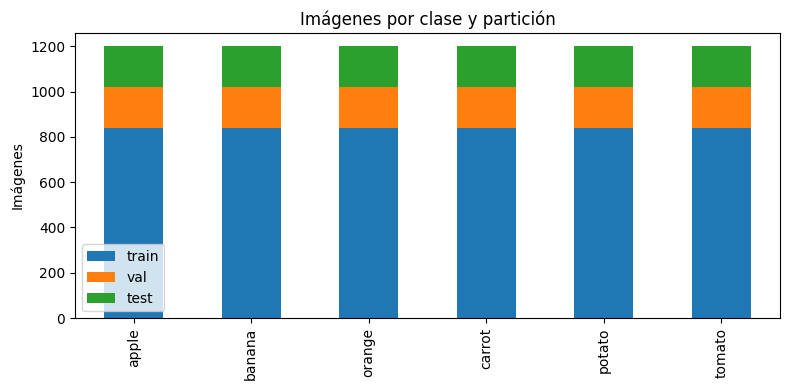

In [6]:
DIR_TRABAJO = Path("/content/fv_dataset")
if DIR_TRABAJO.exists():
    shutil.rmtree(DIR_TRABAJO)

for clase in CLASES:
    archivos = []
    for rel in carpetas_de(clase)["carpeta"]:
        carpeta = Path(ruta_dataset) / rel
        archivos += [p for p in carpeta.iterdir() if p.suffix.lower() in EXT]

    train, resto = train_test_split(archivos, test_size=0.30, random_state=SEED)
    val, test    = train_test_split(resto,    test_size=0.50, random_state=SEED)

    for nombre, lote in [("train", train), ("val", val), ("test", test)]:
        destino = DIR_TRABAJO / nombre / clase
        destino.mkdir(parents=True, exist_ok=True)
        for i, p in enumerate(lote):
            shutil.copy(p, destino / f"{i}_{p.name}")

conteo = pd.DataFrame({
    part: {c: len(list((DIR_TRABAJO / part / c).iterdir())) for c in CLASES}
    for part in ["train", "val", "test"]
})
conteo["total"] = conteo.sum(axis=1)
display(conteo)
conteo[["train", "val", "test"]].plot.bar(stacked=True, figsize=(8, 4), title="Imágenes por clase y partición")
plt.ylabel("Imágenes"); plt.tight_layout(); plt.show()

### 1.5 Preprocesamiento y data augmentation

**Preprocesamiento (todO)**
- Redimensionamiento a un tamaño estándar.
- Normalización de los valores de píxel al rango [0, 1]



In [7]:
def crear_generadores(color_mode="rgb"):
    gen_train = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        brightness_range=(0.6, 1.4),
        fill_mode="nearest",
    )
    gen_eval = ImageDataGenerator(rescale=1./255)

    comunes = dict(target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical", color_mode=color_mode)
    train = gen_train.flow_from_directory(str(DIR_TRABAJO / "train"), shuffle=True,  seed=SEED, **comunes)
    val   = gen_eval.flow_from_directory(str(DIR_TRABAJO / "val"),   shuffle=False, **comunes)
    test  = gen_eval.flow_from_directory(str(DIR_TRABAJO / "test"),  shuffle=False, **comunes)
    return train, val, test

train_gen, val_gen, test_gen = crear_generadores("rgb")
print("Clases:", train_gen.class_indices)

Found 5034 images belonging to 6 classes.
Found 1078 images belonging to 6 classes.
Found 1074 images belonging to 6 classes.
Clases: {'apple': 0, 'banana': 1, 'carrot': 2, 'orange': 3, 'potato': 4, 'tomato': 5}


Se copiaron 5,040, 1,080 y 1,080 imágenes, pero los generadores reportan 5,034, 1,078 y 1,074.

La causa probable es que flow_from_directory ignora algunos formatos, como .webp. La diferencia es menos del 0.2 % y no afecta los resultados, pero conviene mencionarla en el notebook.

Vista previa del *data augmentation*

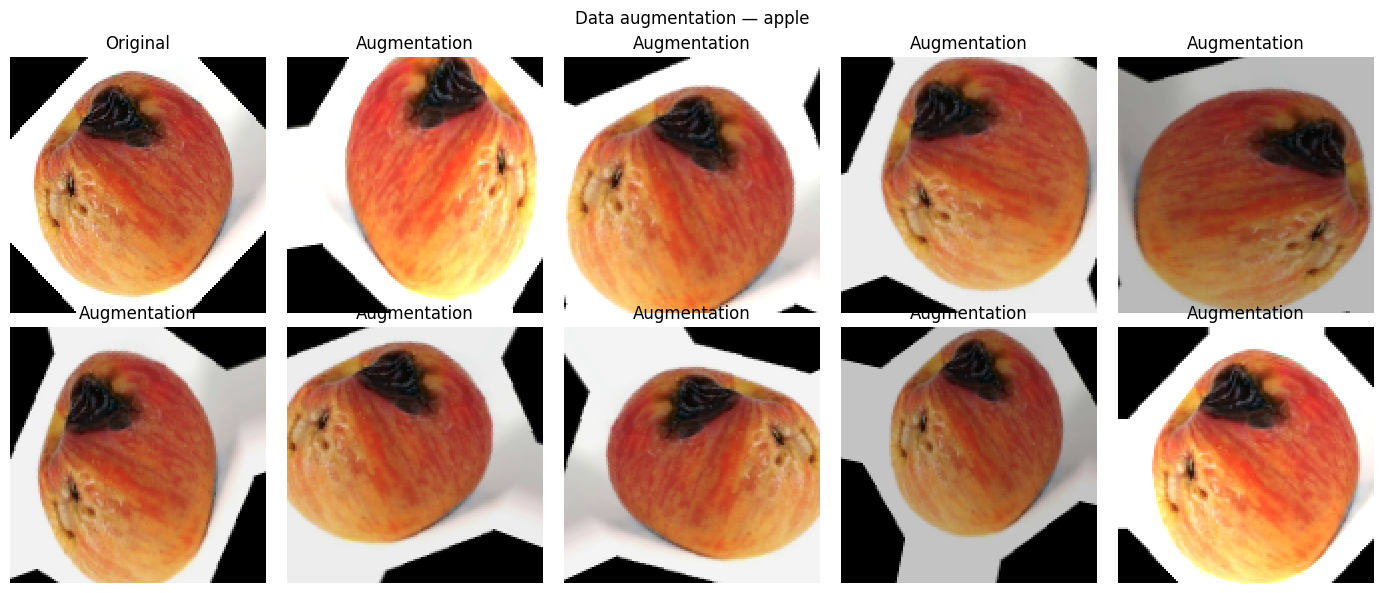

In [8]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

clase_demo = CLASES[0]
ruta_demo  = next((DIR_TRABAJO / "train" / clase_demo).iterdir())
img = img_to_array(load_img(ruta_demo, target_size=IMG_SIZE))[None, ...]

demo_gen = ImageDataGenerator(rescale=1./255, rotation_range=30, zoom_range=0.2,
                              width_shift_range=0.1, height_shift_range=0.1,
                              horizontal_flip=True, brightness_range=(0.6, 1.4), fill_mode="nearest")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0, 0].imshow(img[0].astype("uint8")); axes[0, 0].set_title("Original")
it = demo_gen.flow(img, batch_size=1, seed=SEED)
for ax in list(axes.flat)[1:]:
    ax.imshow(next(it)[0]); ax.set_title("Augmentation")
for ax in axes.flat: ax.axis("off")
plt.suptitle(f"Data augmentation — {clase_demo}")
plt.tight_layout(); plt.show()

## Revisión del brightness_range

Dimensionalidad: (128, 128, 3) | Tipo: uint8 | Rango: [0, 255]


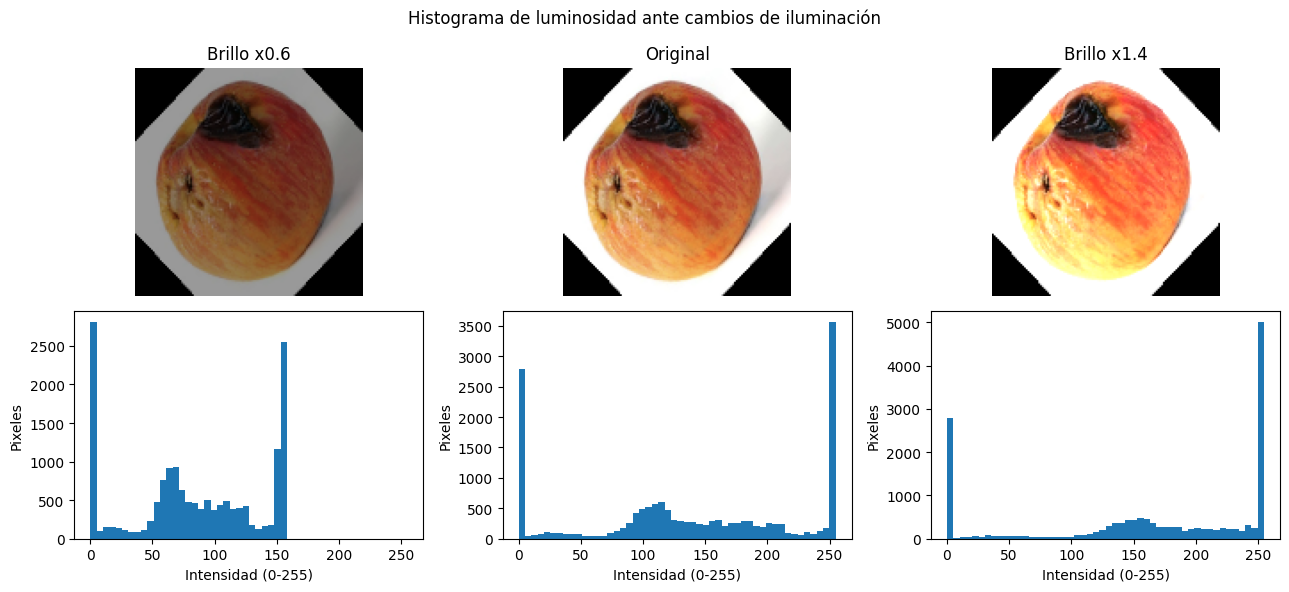

In [9]:
   ruta = next((DIR_TRABAJO / "train" / CLASES[0]).iterdir())
   img = np.array(load_img(ruta, target_size=IMG_SIZE))      # imagen RGB como matriz de valores 0-255
   print(f"Dimensionalidad: {img.shape} | Tipo: {img.dtype} | Rango: [{img.min()}, {img.max()}]")

   versiones = {"Brillo x0.6": np.clip(img * 0.6, 0, 255),
                "Original":    img.astype(float),
                "Brillo x1.4": np.clip(img * 1.4, 0, 255)}

   fig, axes = plt.subplots(2, 3, figsize=(13, 6))
   for col, (nombre, v) in enumerate(versiones.items()):
       gris = 0.3 * v[..., 0] + 0.59 * v[..., 1] + 0.11 * v[..., 2]    # media ponderada vista en clase
       axes[0, col].imshow(v.astype("uint8")); axes[0, col].set_title(nombre); axes[0, col].axis("off")
       axes[1, col].hist(gris.ravel(), bins=50, range=(0, 255))
       axes[1, col].set_xlabel("Intensidad (0-255)"); axes[1, col].set_ylabel("Pixeles")
   plt.suptitle("Histograma de luminosidad ante cambios de iluminación")
   plt.tight_layout(); plt.show()

### 1.6 Escala de grises o color

Se compara la arquitectura entrenada con imágenes **en color (RGB)** y **en escala de grises**

In [10]:
def modelo_A(input_shape, n_clases):
    # Arquitectura base: 2 bloques convolucionales + capa densa
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_clases, activation="softmax"),
    ], name="Modelo_A")
    m.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def entrenar(fabrica, color_mode="rgb", epochs=EPOCHS):
    train, val, test = crear_generadores(color_mode)
    canales = 3 if color_mode == "rgb" else 1
    modelo = fabrica((*IMG_SIZE, canales), train.num_classes)
    cb = [callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
          callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=0)]
    t0 = time.time()
    hist = modelo.fit(train, validation_data=val, epochs=epochs, callbacks=cb, verbose=1)
    return modelo, hist, time.time() - t0, (train, val, test)

In [11]:
comparacion_color = []
for modo in ["rgb", "grayscale"]:
    print(f"\n===== Modelo A — {modo} =====")
    m, h, seg, _ = entrenar(modelo_A, color_mode=modo, epochs=10)
    comparacion_color.append({"formato": modo,
                              "val_accuracy": max(h.history["val_accuracy"]),
                              "val_loss": min(h.history["val_loss"]),
                              "segundos": round(seg)})
comparacion_color = pd.DataFrame(comparacion_color)
comparacion_color


===== Modelo A — rgb =====
Found 5034 images belonging to 6 classes.
Found 1078 images belonging to 6 classes.
Found 1074 images belonging to 6 classes.
Epoch 1/10
 59/158 ━━━━━━━━━━━━━━━━━━━━ 24s 247ms/step - accuracy: 0.2698 - loss: 1.8114

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 279ms/step - accuracy: 0.4718 - loss: 1.3731 - val_accuracy: 0.6781 - val_loss: 1.0033 - learning_rate: 0.0010
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 255ms/step - accuracy: 0.6706 - loss: 0.9253 - val_accuracy: 0.7124 - val_loss: 0.9481 - learning_rate: 0.0010
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 43s 270ms/step - accuracy: 0.7426 - loss: 0.7527 - val_accuracy: 0.7699 - val_loss: 0.7516 - learning_rate: 0.0010
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 260ms/step - accuracy: 0.7720 - loss: 0.6641 - val_accuracy: 0.8080 - val_loss: 0.6275 - learning_rate: 0.0010
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 261ms/step - accuracy: 0.7964 - loss: 0.5987 - val_accuracy: 0.8404 - val_loss: 0.5095 - learning_rate: 0.0010
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 267ms/step - accuracy: 0.8200 - loss: 0.5320 - val_accuracy: 0.8423 - val_loss: 0.5115 - learning_rate: 0.0010
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 54s 342ms/step - accuracy: 0.8393 - loss:

,formato,val_accuracy,val_loss,segundos
0,rgb,0.896104,0.360839,437
1,grayscale,0.636364,0.999311,281


In [12]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Se selecciona el formato con mayor `val_accuracy` en la tabla anterior. Si el color obtiene mejor resultado, el resto del análisis se realiza en RGB (3 canales); en caso contrario, se cambia `COLOR_MODE` en la celda siguiente.

In [14]:
COLOR_MODE = "rgb"

## Parte 2 — Diseño y entrenamiento de la CNN

### 2.1 Arquitecturas

Se definen tres arquitecturas:

| | Modelo A | Modelo B | Modelo C |
|---|---|---|---|
| Capas convolucionales | 2 (32, 64) | 3 (32, 64, 128) | 4 (32, 64, 128, 256) |
| Tamaño de filtros | 3×3 | 3×3 | 5×5 en la primera, 3×3 en el resto |
| Activación | ReLU | ReLU | ReLU |
| Pooling | Max (2×2) | Max (2×2) + Global Average | Average (2×2) + Global Average |
| Regularización | — | BatchNorm + Dropout | BatchNorm + Dropout |
| Capa densa | 64 neuronas | 128 neuronas | 256 neuronas |
| Optimizador | Adam (lr = 1e-3) | Adam (lr = 1e-3) | Adam (lr = 5e-4) |
| Salida | Softmax (6 clases) | Softmax (6 clases) | Softmax (6 clases) |


In [15]:
def modelo_B(input_shape, n_clases):
    # 3 bloques convolucionales con BatchNorm y Dropout, Global Average Pooling
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(n_clases, activation="softmax"),
    ], name="Modelo_B")
    m.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def modelo_C(input_shape, n_clases):
    # 4 bloques convolucionales, filtro inicial 5x5, pooling promedio, BatchNorm y Dropout
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (5, 5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.AveragePooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.AveragePooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.AveragePooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(n_clases, activation="softmax"),
    ], name="Modelo_C")
    m.compile(optimizer=optimizers.Adam(5e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

ARQUITECTURAS = {"Modelo_A": modelo_A, "Modelo_B": modelo_B, "Modelo_C": modelo_C}

for nombre, fabrica in ARQUITECTURAS.items():
    m = fabrica((*IMG_SIZE, 3 if COLOR_MODE == "rgb" else 1), len(CLASES))
    print(f"{nombre}: {m.count_params():,} parámetros")
modelo_B((*IMG_SIZE, 3 if COLOR_MODE == "rgb" else 1), len(CLASES)).summary()

Modelo_A: 3,706,246 parámetros
Modelo_B: 111,430 parámetros
Modelo_C: 459,206 parámetros


Model: "Modelo_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,430 (435.27 KB)

 Trainable params: 110,982 (433.52 KB)

 Non-trainable params: 448 (1.75 KB)

### 2.2 Entrenamiento

- Máximo de `EPOCHS` épocas y `batch_size = 32`.
- `EarlyStopping` sobre `val_loss`
- `ReduceLROnPlateau` reduce a la mitad la tasa de aprendizaje si `val_loss` no mejora.
- Datos de entrenamiento con *data augmentation*; validación sin aumento.

In [16]:
entrenados = {}
for nombre, fabrica in ARQUITECTURAS.items():
    print(f"\n{'=' * 20} {nombre} {'=' * 20}")
    modelo, hist, seg, gens = entrenar(fabrica, color_mode=COLOR_MODE, epochs=15)
    entrenados[nombre] = {"modelo": modelo, "hist": hist, "segundos": seg, "gens": gens}


==================== Modelo_A ====================
Found 5034 images belonging to 6 classes.
Found 1078 images belonging to 6 classes.
Found 1074 images belonging to 6 classes.
Epoch 1/15
  4/158 ━━━━━━━━━━━━━━━━━━━━ 22s 149ms/step - accuracy: 0.1452 - loss: 3.2392

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


158/158 ━━━━━━━━━━━━━━━━━━━━ 46s 277ms/step - accuracy: 0.3655 - loss: 1.5920 - val_accuracy: 0.4814 - val_loss: 1.4520 - learning_rate: 0.0010
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 260ms/step - accuracy: 0.5671 - loss: 1.1626 - val_accuracy: 0.6642 - val_loss: 0.9971 - learning_rate: 0.0010
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.6702 - loss: 0.9159 - val_accuracy: 0.7365 - val_loss: 0.7678 - learning_rate: 0.0010
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - accuracy: 0.7286 - loss: 0.7699 - val_accuracy: 0.7941 - val_loss: 0.6455 - learning_rate: 0.0010
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 264ms/step - accuracy: 0.7664 - loss: 0.6733 - val_accuracy: 0.8098 - val_loss: 0.6192 - learning_rate: 0.0010
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 40s 256ms/step - accuracy: 0.7839 - loss: 0.6208 - val_accuracy: 0.8330 - val_loss: 0.5303 - learning_rate: 0.0010
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 44s 279ms/step - accuracy: 0.7988 - loss:

### 2.3 Curvas de aprendizaje

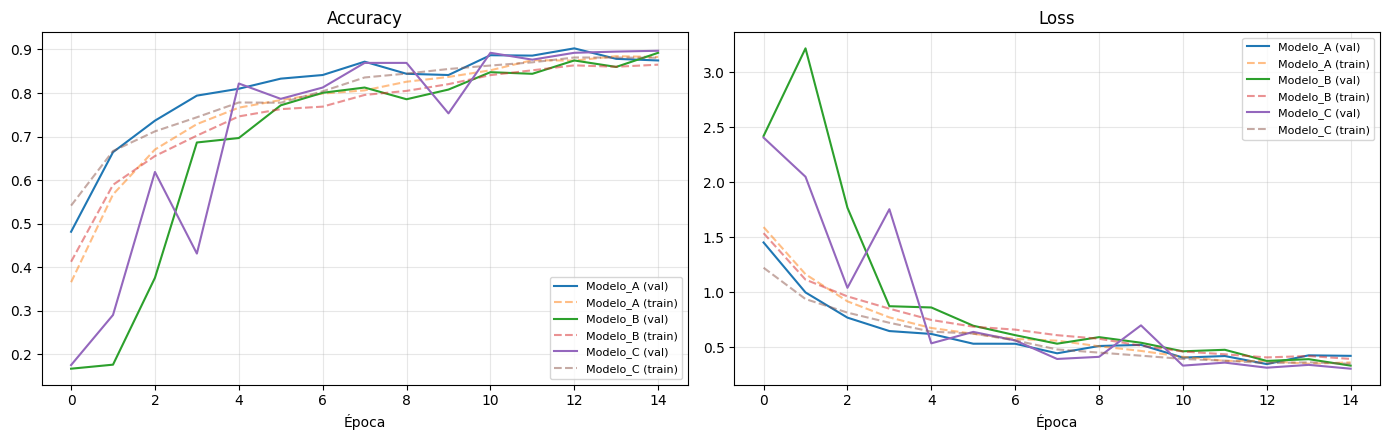

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for nombre, r in entrenados.items():
    h = r["hist"].history
    axes[0].plot(h["val_accuracy"], label=f"{nombre} (val)")
    axes[0].plot(h["accuracy"], linestyle="--", alpha=0.5, label=f"{nombre} (train)")
    axes[1].plot(h["val_loss"], label=f"{nombre} (val)")
    axes[1].plot(h["loss"], linestyle="--", alpha=0.5, label=f"{nombre} (train)")
axes[0].set_title("Accuracy"); axes[1].set_title("Loss")
for ax in axes:
    ax.set_xlabel("Época"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2.4 Comparación de arquitecturas

La selección del mejor modelo se basa en el desempeño sobre **validación**.

In [18]:
filas = []
for nombre, r in entrenados.items():
    train, val, test = r["gens"]
    h = r["hist"].history
    val_loss, val_acc   = r["modelo"].evaluate(val,  verbose=0)
    test_loss, test_acc = r["modelo"].evaluate(test, verbose=0)
    filas.append({
        "modelo": nombre,
        "parámetros": r["modelo"].count_params(),
        "épocas": len(h["loss"]),
        "train_acc": round(h["accuracy"][-1], 4),
        "val_acc": round(val_acc, 4),
        "test_acc": round(test_acc, 4),
        "test_loss": round(test_loss, 4),
        "tiempo (s)": round(r["segundos"]),
    })
tabla = pd.DataFrame(filas).set_index("modelo")
mejor = tabla["val_acc"].idxmax()
display(tabla)
print("Mejor modelo según validación:", mejor)

,parámetros,épocas,train_acc,val_acc,test_acc,test_loss,tiempo (s)
modelo,,,,,,,
Modelo_A,3706246,15,0.8828,0.9026,0.9013,0.3039,621
Modelo_B,111430,15,0.8651,0.8924,0.8734,0.3534,644
Modelo_C,459206,15,0.8810,0.8970,0.9022,0.2849,636


Mejor modelo según validación: Modelo_A


### 2.5 Evaluación detallada del mejor modelo (conjunto de prueba)

=== Modelo_A — reporte de clasificación (prueba) ===
              precision    recall  f1-score   support

       apple      0.865     0.865     0.865       178
      banana      0.893     0.893     0.893       178
      carrot      0.936     0.905     0.920       179
      orange      0.943     0.911     0.927       180
      potato      0.890     0.905     0.898       179
      tomato      0.884     0.928     0.905       180

    accuracy                          0.901      1074
   macro avg      0.902     0.901     0.901      1074
weighted avg      0.902     0.901     0.901      1074



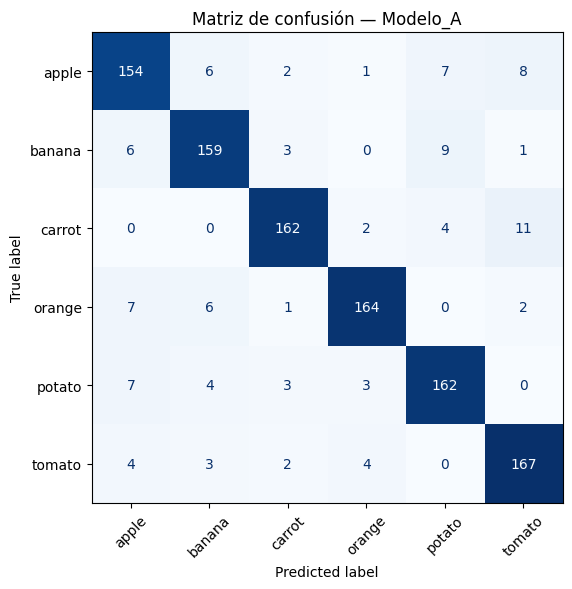

In [19]:
r = entrenados[mejor]
_, _, test = r["gens"]

probs  = r["modelo"].predict(test, verbose=0)
y_pred = probs.argmax(axis=1)
y_true = test.classes
nombres = list(test.class_indices.keys())

print(f"=== {mejor} — reporte de clasificación (prueba) ===")
print(classification_report(y_true, y_pred, target_names=nombres, digits=3))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=nombres).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión — {mejor}")
plt.tight_layout(); plt.show()

Ejemplos de imágenes mal clasificadas

Errores: 106 de 1074 imágenes de prueba


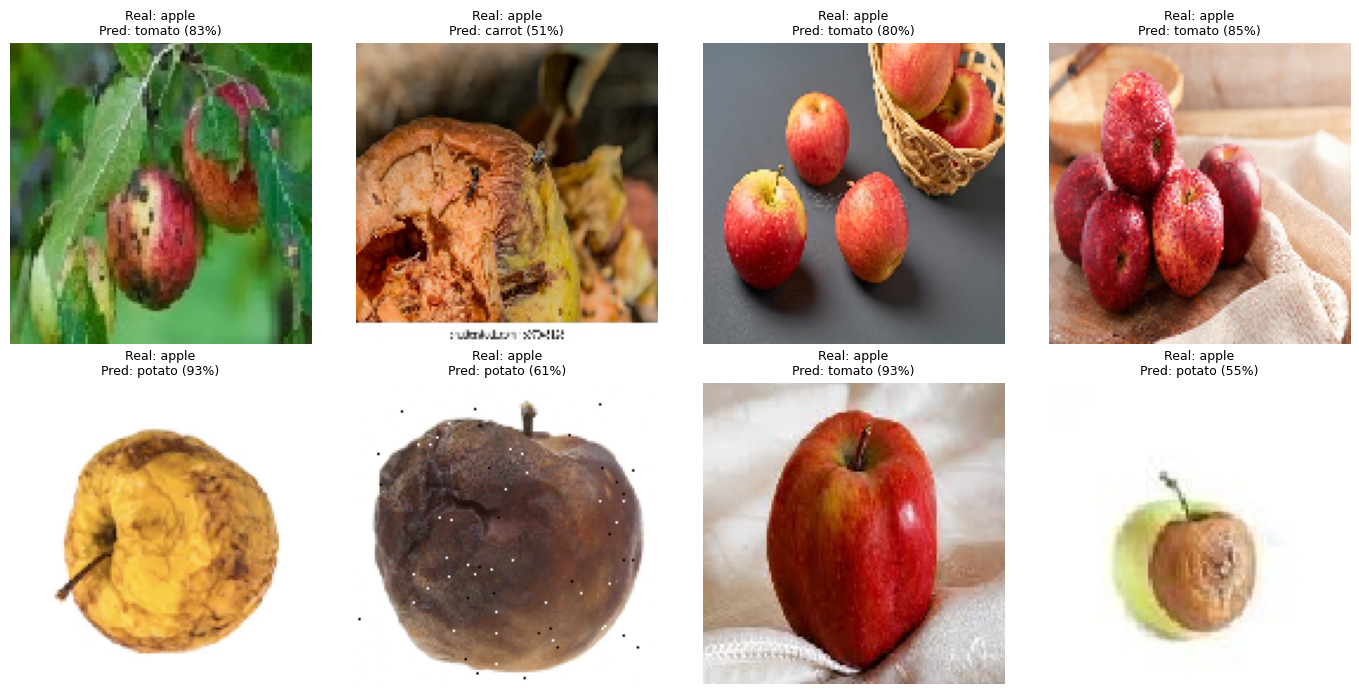

In [20]:
errores = np.where(y_pred != y_true)[0]
print(f"Errores: {len(errores)} de {len(y_true)} imágenes de prueba")

if len(errores) > 0:
    muestra = errores[:8]
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, i in zip(axes.flat, muestra):
        ruta = test.filepaths[i]
        ax.imshow(load_img(ruta, target_size=IMG_SIZE))
        ax.set_title(f"Real: {nombres[y_true[i]]}\nPred: {nombres[y_pred[i]]} ({probs[i].max():.0%})", fontsize=9)
    for ax in axes.flat: ax.axis("off")
    plt.tight_layout(); plt.show()

In [21]:
r["modelo"].save("mejor_cnn_frutas_vegetales.keras")
print("Modelo guardado:", "mejor_cnn_frutas_vegetales.keras")

Modelo guardado: mejor_cnn_frutas_vegetales.keras


## Conclusiones


**Formato de imagen:** se utilizó color (RGB). En la comparación con la arquitectura base RGB alcanzó una `val_accuracy` de 0.896 frente a 0.636 en escala de grises.

Como se vio en clase, la escala de grises reduce la información de 3 canales a 1; en este problema esa reducción elimina el color, que es una característica discriminante entre frutas y vegetales (por ejemplo, el amarillo de la banana o el rojo del tomate).

**Errores frecuentes:** el Modelo A alcanzó una exactitud de 0.901 en prueba (106 errores de 1,074 imágenes).
La clase con menor desempeño fue *apple* (recall y precisión de 0.865).

Las confusiones más frecuentes fueron zanahoria→tomate (11), banana→papa (9) y manzana→tomate (8).

Al revisar las imágenes mal clasificadas, se observan dos causas: manzanas rojas y brillantes con color y forma similares a los tomates, y frutas en descomposición, cuyo color y textura marrón se asemejan a los de la papa o la zanahoria. Como cada clase incluye imágenes frescas y podridas, sus ejemplos son visualmente heterogéneos, lo que dificulta la separación.